In [53]:
import numpy as np
import scipy.special



In [54]:
def modmc1(m, q, x):
    return scipy.special.mathieu_modcem1(m, q, x)
def modmc2(m, q, x):
    return scipy.special.mathieu_modcem2(m, q, x)

def modms1(m, q, x):
    return scipy.special.mathieu_modsem1(m, q, x)
def modms2(m, q, x):
    return scipy.special.mathieu_modsem2(m, q, x)

def mathieu_a(m, q):
    return scipy.special.mathieu_a(m, q)

def mathieu_b(m, q):
    return scipy.special.mathieu_b(m, q)



In [55]:
# Round trip modmc1
NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)



error = []

for m in range(MM):
    for q in qs:
        fm3 = modmc1(m, q, v - 3 * h)[1]
        fm2 = modmc1(m, q, v - 2 * h)[1]
        fm1 = modmc1(m, q, v - h)[1]
        fp1 = modmc1(m, q, v + h)[1]
        fp2 = modmc1(m, q, v + 2 * h)[1]
        fp3 = modmc1(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modmc1(m,q,v)
        a = mathieu_a(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) / np.sqrt(len(y))

        error.append( l2norm)
        if not np.isclose( l2norm , 0, atol=tol):
            
            print(f'm = {m}, q = {q}, error = {l2norm}')




m = 0, q = 0.0001, error = 0.9208188940744474
m = 0, q = 0.00046415888336127773, error = 0.784179207980395
m = 0, q = 0.002154434690031882, error = 0.6247934659388709
m = 0, q = 0.01, error = 0.42152170451596926
m = 0, q = 0.046415888336127774, error = 0.22163277040139695
m = 0, q = 0.21544346900318823, error = 0.1834968663545357
m = 0, q = 1.0, error = 0.11613876676979244
m = 0, q = 4.641588833612772, error = 0.08141745320959881
m = 0, q = 21.54434690031882, error = 0.05363236321490723
m = 0, q = 100.0, error = 0.03391468786415905
m = 1, q = 0.0001, error = 0.26589383464254734
m = 1, q = 0.00046415888336127773, error = 0.3691397791629016
m = 1, q = 0.002154434690031882, error = 0.382013169283949
m = 1, q = 0.01, error = 0.37217354297984545
m = 1, q = 0.046415888336127774, error = 0.2951749199146213
m = 1, q = 0.21544346900318823, error = 0.1609369635397771
m = 1, q = 1.0, error = 0.11965715161638009
m = 1, q = 4.641588833612772, error = 0.07796988385994476
m = 1, q = 21.54434690031882

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
    

M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)

df_error = pd.DataFrame(error_array, index=range(MM), columns=qs)

plt.figure(figsize=(8, 6))
sns.heatmap(df_error, vmin=20, vmax=80, annot=True, fmt=".1f", cmap="viridis")
plt.title("Heatmap with Custom Value Range")
plt.show()

# fig, ax = plt.subplots()
# im = ax.pcolormesh(range(MM), np.log10(qs), error_array, cmap='viridis')

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label('Value')

# ax.set_title("Round Trip Error for modcm1")
# ax.set_xlabel("m")
# ax.set_ylabel("log10(q)")

# plt.show()

NameError: name 'pd' is not defined

In [ ]:
# Round trip modmc2

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,4,10)
error = []
for m in range(MM):
    for q in qs:
        fm3 = modmc2(m, q, v - 3 * h)[1]
        fm2 = modmc2(m, q, v - 2 * h)[1]
        fm1 = modmc2(m, q, v - h)[1]
        fp1 = modmc2(m, q, v + h)[1]
        fp2 = modmc2(m, q, v + 2 * h)[1]
        fp3 = modmc2(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modmc2(m,q,v)
        a = mathieu_a(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        # stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) / np.sqrt(len(y))

        error.append( l2norm)
        if not np.isclose( l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = {l2norm}')



m = 0, q = 0.0001, error = 0.9420240036876363
m = 0, q = 0.000774263682681127, error = 0.5118103471208666
m = 0, q = 0.005994842503189409, error = 0.29723173588757607
m = 0, q = 0.046415888336127774, error = 0.2767478077400959
m = 0, q = 0.3593813663804626, error = 0.15589650185033507
m = 0, q = 2.782559402207126, error = 0.0909470767834755
m = 0, q = 21.54434690031882, error = 0.05487262454524635
m = 0, q = 166.81005372000558, error = 0.03514940344919177
m = 0, q = 1291.5496650148827, error = 0.017995391711820685
m = 0, q = 10000.0, error = nan
m = 1, q = 0.0001, error = 3.6455303386217524
m = 1, q = 0.000774263682681127, error = 1.3957746388219412
m = 1, q = 0.005994842503189409, error = 0.5511523960070354
m = 1, q = 0.046415888336127774, error = 0.21610356377599033
m = 1, q = 0.3593813663804626, error = 0.14485092839233402
m = 1, q = 2.782559402207126, error = 0.09123725613674576
m = 1, q = 21.54434690031882, error = 0.053636429828990896
m = 1, q = 166.81005372000558, error = 0.0308

/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2791: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


m = 77, q = 1291.5496650148827, error = 0.02035917681887691
m = 77, q = 10000.0, error = nan
m = 78, q = 0.0001, error = nan
m = 78, q = 0.000774263682681127, error = inf
m = 78, q = 0.005994842503189409, error = inf
m = 78, q = 0.046415888336127774, error = 2.5157731684737936e+119
m = 78, q = 0.3593813663804626, error = 5.729488377924101e+84
m = 78, q = 2.782559402207126, error = 1.8999328037560275e+50
m = 78, q = 21.54434690031882, error = 1.2627469621767944e+17
m = 78, q = 166.81005372000558, error = 0.03480605256897738
m = 78, q = 1291.5496650148827, error = 0.020535340995513907
m = 78, q = 10000.0, error = nan
m = 79, q = 0.0001, error = nan
m = 79, q = 0.000774263682681127, error = nan
m = 79, q = 0.005994842503189409, error = inf
m = 79, q = 0.046415888336127774, error = 2.4644149628379146e+121
m = 79, q = 0.3593813663804626, error = 2.0155963026166125e+86
m = 79, q = 2.782559402207126, error = 2.3886706349024098e+51
m = 79, q = 21.54434690031882, error = 5.443999284424532e+17
m

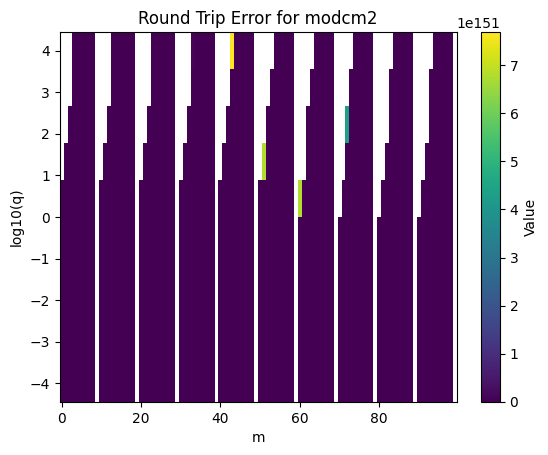

In [ ]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)

fig, ax = plt.subplots()
im = ax.pcolormesh(range(MM), np.log10(qs), error_array, cmap='viridis')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Value')

ax.set_title("Round Trip Error for modcm2")
ax.set_xlabel("m")
ax.set_ylabel("log10(q)")

plt.show()

In [ ]:
import math
# Round trip modms1

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)
error = []

for m in range(1, MM):
    for q in qs:
        fm3 = modms1(m, q, v - 3 * h)[1]
        fm2 = modms1(m, q, v - 2 * h)[1]
        fm1 = modms1(m, q, v - h)[1]
        fp1 = modms1(m, q, v + h)[1]
        fp2 = modms1(m, q, v + 2 * h)[1]
        fp3 = modms1(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modms1(m,q,v)
        a = mathieu_b(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        # stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) / np.sqrt(len(y))

        
        error.append(l2norm)
        if not np.isclose( l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = {l2norm}')



m = 1, q = 0.0001, error = 0.2657283527148938
m = 1, q = 0.00046415888336127773, error = 0.3687305772367246
m = 1, q = 0.002154434690031882, error = 0.38087504900696156
m = 1, q = 0.01, error = 0.3698187972084716
m = 1, q = 0.046415888336127774, error = 0.2936912980309797
m = 1, q = 0.21544346900318823, error = 0.16007864538490796
m = 1, q = 1.0, error = 0.11822962623221209
m = 1, q = 4.641588833612772, error = 0.07792423093963653
m = 1, q = 21.54434690031882, error = 0.05487262456897547
m = 1, q = 100.0, error = 0.03975698134371068
m = 2, q = 0.0001, error = 0.07182676755136713
m = 2, q = 0.00046415888336127773, error = 0.21115989644471375
m = 2, q = 0.002154434690031882, error = 0.2598722193588895
m = 2, q = 0.01, error = 0.273965395484185
m = 2, q = 0.046415888336127774, error = 0.2708591800769096
m = 2, q = 0.21544346900318823, error = 0.18282014706105368
m = 2, q = 1.0, error = 0.11466536722460632
m = 2, q = 4.641588833612772, error = 0.08178442746919393
m = 2, q = 21.544346900318

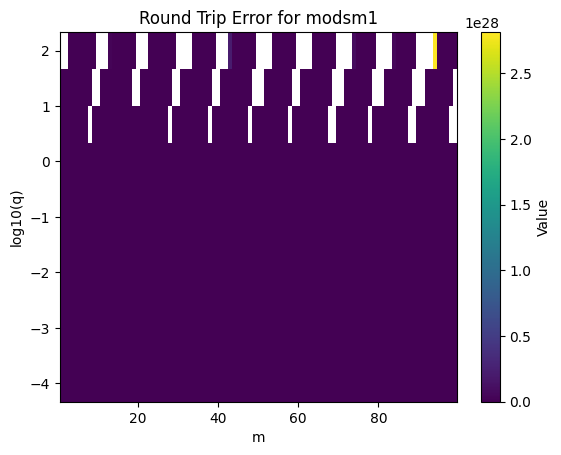

In [ ]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(1,MM), qs)

error_array = np.array(error).reshape(M.shape)


fig, ax = plt.subplots()
im = ax.pcolormesh(range(1, MM), np.log10(qs), error_array, cmap='viridis')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Value')

ax.set_title("Round Trip Error for modsm1")
ax.set_xlabel("m")
ax.set_ylabel("log10(q)")

plt.show()

In [ ]:
# Round trip modms2

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)
error = []

for m in range(1, MM):
    for q in qs:
        fm3 = modms2(m, q, v - 3 * h)[1]
        fm2 = modms2(m, q, v - 2 * h)[1]
        fm1 = modms2(m, q, v - h)[1]
        fp1 = modms2(m, q, v + h)[1]
        fp2 = modms2(m, q, v + 2 * h)[1]
        fp3 = modms2(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modms2(m,q,v)
        a = mathieu_b(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        # stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) / np.sqrt(len(y))
        error.append( l2norm)

        if not np.isclose(l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = { l2norm}')



m = 1, q = 0.0001, error = 3.64474606488172
m = 1, q = 0.00046415888336127773, error = 1.7610723211642987
m = 1, q = 0.002154434690031882, error = 0.8793409532116161
m = 1, q = 0.01, error = 0.42983563862016017
m = 1, q = 0.046415888336127774, error = 0.21629335075523964
m = 1, q = 0.21544346900318823, error = 0.18442924834485538
m = 1, q = 1.0, error = 0.11601428589843146
m = 1, q = 4.641588833612772, error = 0.08141832046371156
m = 1, q = 21.54434690031882, error = 0.05363236320791733
m = 1, q = 100.0, error = 0.03391468786415903
m = 2, q = 0.0001, error = 69.20755315426305
m = 2, q = 0.00046415888336127773, error = 15.062607191816692
m = 2, q = 0.002154434690031882, error = 3.4090545896029143
m = 2, q = 0.01, error = 0.902625200484839
m = 2, q = 0.046415888336127774, error = 0.31068115879422675
m = 2, q = 0.21544346900318823, error = 0.17138607322175323
m = 2, q = 1.0, error = 0.12107412460728165
m = 2, q = 4.641588833612772, error = 0.0779780350257556
m = 2, q = 21.54434690031882, 

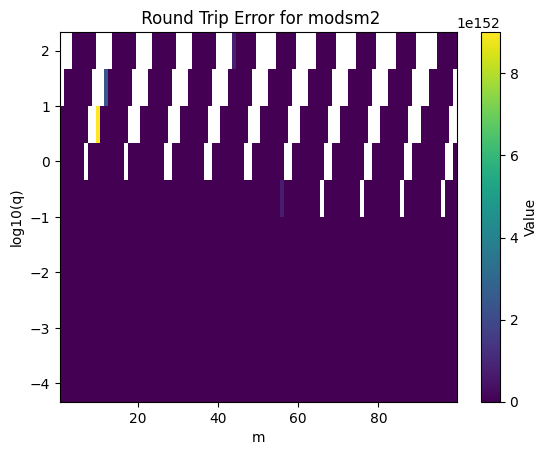

In [ ]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(1,MM), qs)

error_array = np.array(error).reshape(M.shape)


fig, ax = plt.subplots()
im = ax.pcolormesh(range(1, MM), np.log10(qs), error_array, cmap='viridis')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Value')

ax.set_title(" Round Trip Error for modsm2")
ax.set_xlabel("m")
ax.set_ylabel("log10(q)")

plt.show()